# 의왕시 정보공개청구 현황 분석
## 태스크 3: 청구인 유형별 핵심 키워드 추출  |  태스크 4: 유사·반복 청구 분석

- **분석 기간**: 2025년 1월 1일 ~ 12월 31일
- **분석 도구**: Python (Jupyter Notebook)
- **형태소 분석기**: Komoran
- **유사도 방법**: TF-IDF + 코사인 유사도
- **유사·반복 청구 임계값**: 0.85

In [10]:
import os
import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter, defaultdict
from konlpy.tag import Komoran
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ──
FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
FONT_NAME = font_prop.get_name()

# ※ sns.set_theme()은 matplotlib rcParams를 덮어쓰므로
#   rc= 인자로 폰트 설정을 함께 전달해야 한글이 깨지지 않음
sns.set_theme(style='whitegrid', rc={
    'font.family': FONT_NAME,
    'axes.unicode_minus': False,
    'figure.dpi': 150,
})

def fix_korean_font(fig):
    """Figure 내 모든 Text 객체에 한글 폰트 강제 적용 (savefig 직전 호출)"""
    for text_obj in fig.findobj(plt.Text):
        text_obj.set_fontfamily(FONT_NAME)

# ── 라벨/출력명 설정 (여기만 바꾸면 전체 시각화 라벨 변경) ──
TERM_REQUEST = '청구'
TERM_SIM_REPEAT = '유사·반복 청구'
COUNT_UNIT = '건'

LABEL_TASK3_BAR_TITLE = f'청구인 유형별 TF-IDF 핵심 키워드 Top 10'
LABEL_TASK3_BAR_X = '평균 TF-IDF 점수'
LABEL_TASK3_HEATMAP_TITLE = '청구인 유형별 상위 키워드 TF-IDF 점수 비교'
LABEL_TASK3_HEATMAP_X = '청구인 유형'
LABEL_TASK3_HEATMAP_Y = '키워드'

LABEL_TASK4_SIM_HIST_TITLE = f'{TERM_SIM_REPEAT} 유사도 분포'
LABEL_TASK4_SIM_HIST_SUB_ALL = '전체 문서쌍 유사도 분포 (>0.01)'
LABEL_TASK4_SIM_HIST_SUB_HIGH = '유사도 >= 0.3 구간 확대'
LABEL_TASK4_SIM_X = '코사인 유사도'
LABEL_TASK4_SIM_Y = '문서쌍 수'

LABEL_TASK4_CLUSTER_BAR_TITLE = f'상위 15 {TERM_SIM_REPEAT} 클러스터 크기'
LABEL_TASK4_CLUSTER_BAR_X = f'{TERM_REQUEST} 문서 수'
LABEL_TASK4_CLUSTER_BUBBLE_TITLE = f'{TERM_SIM_REPEAT} 클러스터 산점도(버블)\n(순위별 클러스터 규모와 대표유형)'
LABEL_TASK4_CLUSTER_BUBBLE_X = f'클러스터 순위({TERM_REQUEST} 문서수 내림차순)'
LABEL_TASK4_CLUSTER_BUBBLE_Y = '클러스터 문서 수'

FILE_TASK4_SIM_HIST = '태스크4_유사_반복_청구_유사도분포_히스토그램.png'
FILE_TASK4_CLUSTER_BAR = '태스크4_유사_반복_청구_클러스터크기_막대그래프.png'
FILE_TASK4_CLUSTER_BUBBLE = '태스크4_유사_반복_청구_클러스터_산점도.png'
FILE_SIM_REPEAT_KEYWORD = '유사_반복_청구_핵심키워드.csv'
FILE_SIM_REPEAT_CLUSTER_SUM = '유사_반복_청구_클러스터요약.csv'
FILE_SIM_REPEAT_RECEIPT = '유사_반복_청구_접수번호.txt'
FILE_SIM_REPEAT_CLUSTER_LIST_CSV = '유사_반복_청구_클러스터_전체목록.csv'
FILE_SIM_REPEAT_CLUSTER_LIST_TXT = '유사_반복_청구_클러스터_전체목록.txt'

# ── 경로 설정 ──
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
EXCEL_PATH = os.path.normpath(os.path.join(BASE_DIR, '..', 'report',
    '의왕시 정보공개청구 현황(2025-01-01_2025-12-31).xlsx'))
SHEET_NAME = '청구서전체현황(2025-01-01_2025-12-31)'
OUTPUT_DIR = BASE_DIR

TOP_N = 15
SIMILARITY_THRESHOLD = 0.85

# ── 형태소 분석기 ──
komoran = Komoran()

# ── 띄어쓰기 보정 (PyKoSpacing) ──
USE_SPACING = True   # False로 변경하면 띄어쓰기 보정을 건너뜁니다 (속도 빠름)
if USE_SPACING:
    try:
        from pykospacing import Spacing
        spacing_model = Spacing()
        print('PyKoSpacing 로딩 완료')
    except ImportError:
        USE_SPACING = False
        print('PyKoSpacing 미설치 - 띄어쓰기 보정 생략')

# ── 불용어 ──
STOPWORDS = {
    '청구','정보','공개','내용','제목','자료','관련','요청','사항','경우','확인',
    '본인','의왕시','의왕','현황','공개청구','정보공개','내역','처리','결과',
    '대상','제공','범위','기준','일자','항목','전체','부분','사유','업무','기관',
    '부탁','문의','대한','통한','위한','첨부','파일','가능','요청사항',
    '회신','신청','통지','부서','완료','접수','기간','목적','조사','전국',
    '문서','오프라인','직접','방문','온라인','모바일','우편','대한민국',
    '하반기','상반기','연도','년도',
}

print('라이브러리 및 설정 로딩 완료')

PyKoSpacing 로딩 완료
라이브러리 및 설정 로딩 완료


In [11]:
# ── 데이터 로딩 ──
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
print(f'전체 문서 수: {len(df):,}건')
print(f'컬럼: {df.columns.tolist()}')
print()
print('구분별 건수:')
display(df['구분'].value_counts().to_frame('건수'))
print()
print('주요 컬럼 NULL 현황:')
display(df[['청구제목','청구내용','구분','처리상태','청구방법']].isnull().sum().to_frame('결측수'))

전체 문서 수: 3,007건
컬럼: ['접수번호', '접수일', '구분', '청구제목', '청구내용', '공개방법', '처리부서', '결정구분', '공개내용', '비공개(부분 공개)내용 및 사유', '비공개사유', '결정통지일', '공개일', '공개형태', '교부방법', '처리상태', '청구방법', '처리자', '처리기한', '처리완료일자', '처리기간', '부존재사유', '연장통지일자', '다중처리여부', '수수료 감면 신청여부', '수수료 감면 사유', '수수료금액', '수수료납부여부', '수수료납부형태']

구분별 건수:


,건수
구분,
개인(내국인),2678
법인(국내),245
단체,82
개인(외국인),2



주요 컬럼 NULL 현황:


,결측수
청구제목,0
청구내용,0
구분,0
처리상태,0
청구방법,0


In [12]:
# ── 전처리 함수 정의 ──
def clean_text(text):
    """텍스트 정제: 특수문자 정리, 공백 정규화"""
    if text is None or (isinstance(text, float) and math.isnan(text)):
        return ''
    text = str(text)
    text = text.replace('\u3000', ' ').replace('\xa0', ' ')
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_valid_token(token):
    """토큰 유효성 검사"""
    token = token.strip()
    if not token or len(token) <= 1:
        return False
    if token in STOPWORDS:
        return False
    if re.fullmatch(r'\d+[년월일호회번]?', token):
        return False
    if re.fullmatch(r'[a-zA-Z]+', token):
        return False
    if token in {'제','등','및','내','수','건'}:
        return False
    return True

def tokenize_text(text):
    """Komoran 형태소 분석기로 명사 추출"""
    if not text.strip():
        return []
    try:
        tokens = [t.strip() for t in komoran.nouns(text)]
        return [t for t in tokens if is_valid_token(t)]
    except:
        return []

def normalize_type(value):
    """청구인 유형 정규화"""
    text = str(value).strip()
    if '개인' in text: return '개인'
    if '법인' in text: return '법인'
    if '단체' in text: return '단체'
    return '기타'

def safe_spacing(text, max_len=500):
    """안전한 띄어쓰기 보정"""
    if not text or not USE_SPACING:
        return text
    try:
        return spacing_model(text[:max_len]) if len(text) > max_len else spacing_model(text)
    except:
        return text

# ── 전처리 실행 (캐시 지원) ──
CACHE_PATH = os.path.join(OUTPUT_DIR, '_preprocessed_cache.pkl')

if os.path.exists(CACHE_PATH):
    print('전처리 캐시 파일 발견 → 로딩 중...')
    df_valid = pd.read_pickle(CACHE_PATH)
    empty_count = len(df) - len(df_valid)
    print(f'\n캐시 로딩 완료')
    print(f'  유효 문서: {len(df_valid):,}건 / 빈 문서: {empty_count}건')
    print()
    display(df_valid['청구인유형'].value_counts().to_frame('건수'))
else:
    print('[1/4] 텍스트 정제 중...')
    df['청구인유형'] = df['구분'].apply(normalize_type)
    df['청구제목_clean'] = df['청구제목'].apply(clean_text)
    df['청구내용_clean'] = df['청구내용'].apply(clean_text)

    print('[2/4] 띄어쓰기 보정 중... (약 5~15분 소요될 수 있음)')
    df['청구제목_보정'] = df['청구제목_clean'].apply(safe_spacing)
    df['청구내용_보정'] = df['청구내용_clean'].apply(safe_spacing)
    df['결합텍스트'] = (df['청구제목_보정'] + ' ' + df['청구내용_보정']).apply(clean_text)

    print('[3/4] 형태소 분석(Komoran) 중...')
    df['결합토큰'] = df['결합텍스트'].apply(tokenize_text)
    df['결합문서'] = df['결합토큰'].apply(lambda t: ' '.join(t))

    print('[4/4] 빈 문서 확인 중...')
    empty_mask = df['결합문서'].str.strip() == ''
    df_valid = df[~empty_mask].copy().reset_index(drop=True)

    # 캐시 저장
    df_valid.to_pickle(CACHE_PATH)

    print(f'\n전처리 완료 (캐시 저장: _preprocessed_cache.pkl)')
    print(f'  유효 문서: {len(df_valid):,}건 / 빈 문서: {empty_mask.sum()}건')
    print()
    display(df_valid['청구인유형'].value_counts().to_frame('건수'))

전처리 캐시 파일 발견 → 로딩 중...

캐시 로딩 완료
  유효 문서: 2,996건 / 빈 문서: 11건



,건수
청구인유형,
개인,2669
법인,245
단체,82


---
## 태스크 3: 청구인 유형별 핵심 키워드 추출

청구인 유형(개인·법인·단체)별로 청구 제목과 내용에서 TF-IDF 및 빈도 기반 핵심 키워드를 추출하여,  
유형 간 **요구 정보의 성향 차이**를 분석한다.

In [4]:
# ── 유형별 TF-IDF & 빈도 키워드 추출 ──
keyword_results = {}

for utype in ['개인', '법인', '단체']:
    subset = df_valid[df_valid['청구인유형'] == utype]
    docs = subset['결합문서'].tolist()
    valid_docs = [d for d in docs if d.strip()]
    
    if not valid_docs:
        continue
    
    # TF-IDF 키워드
    vectorizer = TfidfVectorizer(
        token_pattern=r'(?u)\b\w+\b',
        min_df=2, max_df=0.85,
        sublinear_tf=True
    )
    matrix = vectorizer.fit_transform(valid_docs)
    feature_names = np.array(vectorizer.get_feature_names_out())
    mean_scores = np.asarray(matrix.mean(axis=0)).ravel()
    top_idx = np.argsort(mean_scores)[::-1][:TOP_N]
    tfidf_kw = [(feature_names[i], mean_scores[i]) for i in top_idx if mean_scores[i] > 0]
    
    # 빈도 키워드
    all_tokens = [t for tokens in subset['결합토큰'] for t in tokens]
    freq_kw = Counter(all_tokens).most_common(TOP_N)
    
    keyword_results[utype] = {
        'tfidf': tfidf_kw,
        'freq': freq_kw,
        'count': len(subset)
    }
    
    print(f'[{utype}] (n={len(subset):,}) 상위 TF-IDF: {[w for w,s in tfidf_kw[:5]]}')

print('\n키워드 추출 완료')

[개인] (n=2,669) 상위 TF-IDF: ['번호', '영상', '감사', '시설', '업체']
[법인] (n=245) 상위 TF-IDF: ['처분', '행정', '확인서', '관리', '감사']
[단체] (n=82) 상위 TF-IDF: ['신고', '업소', '행정', '폐업', '처분']

키워드 추출 완료


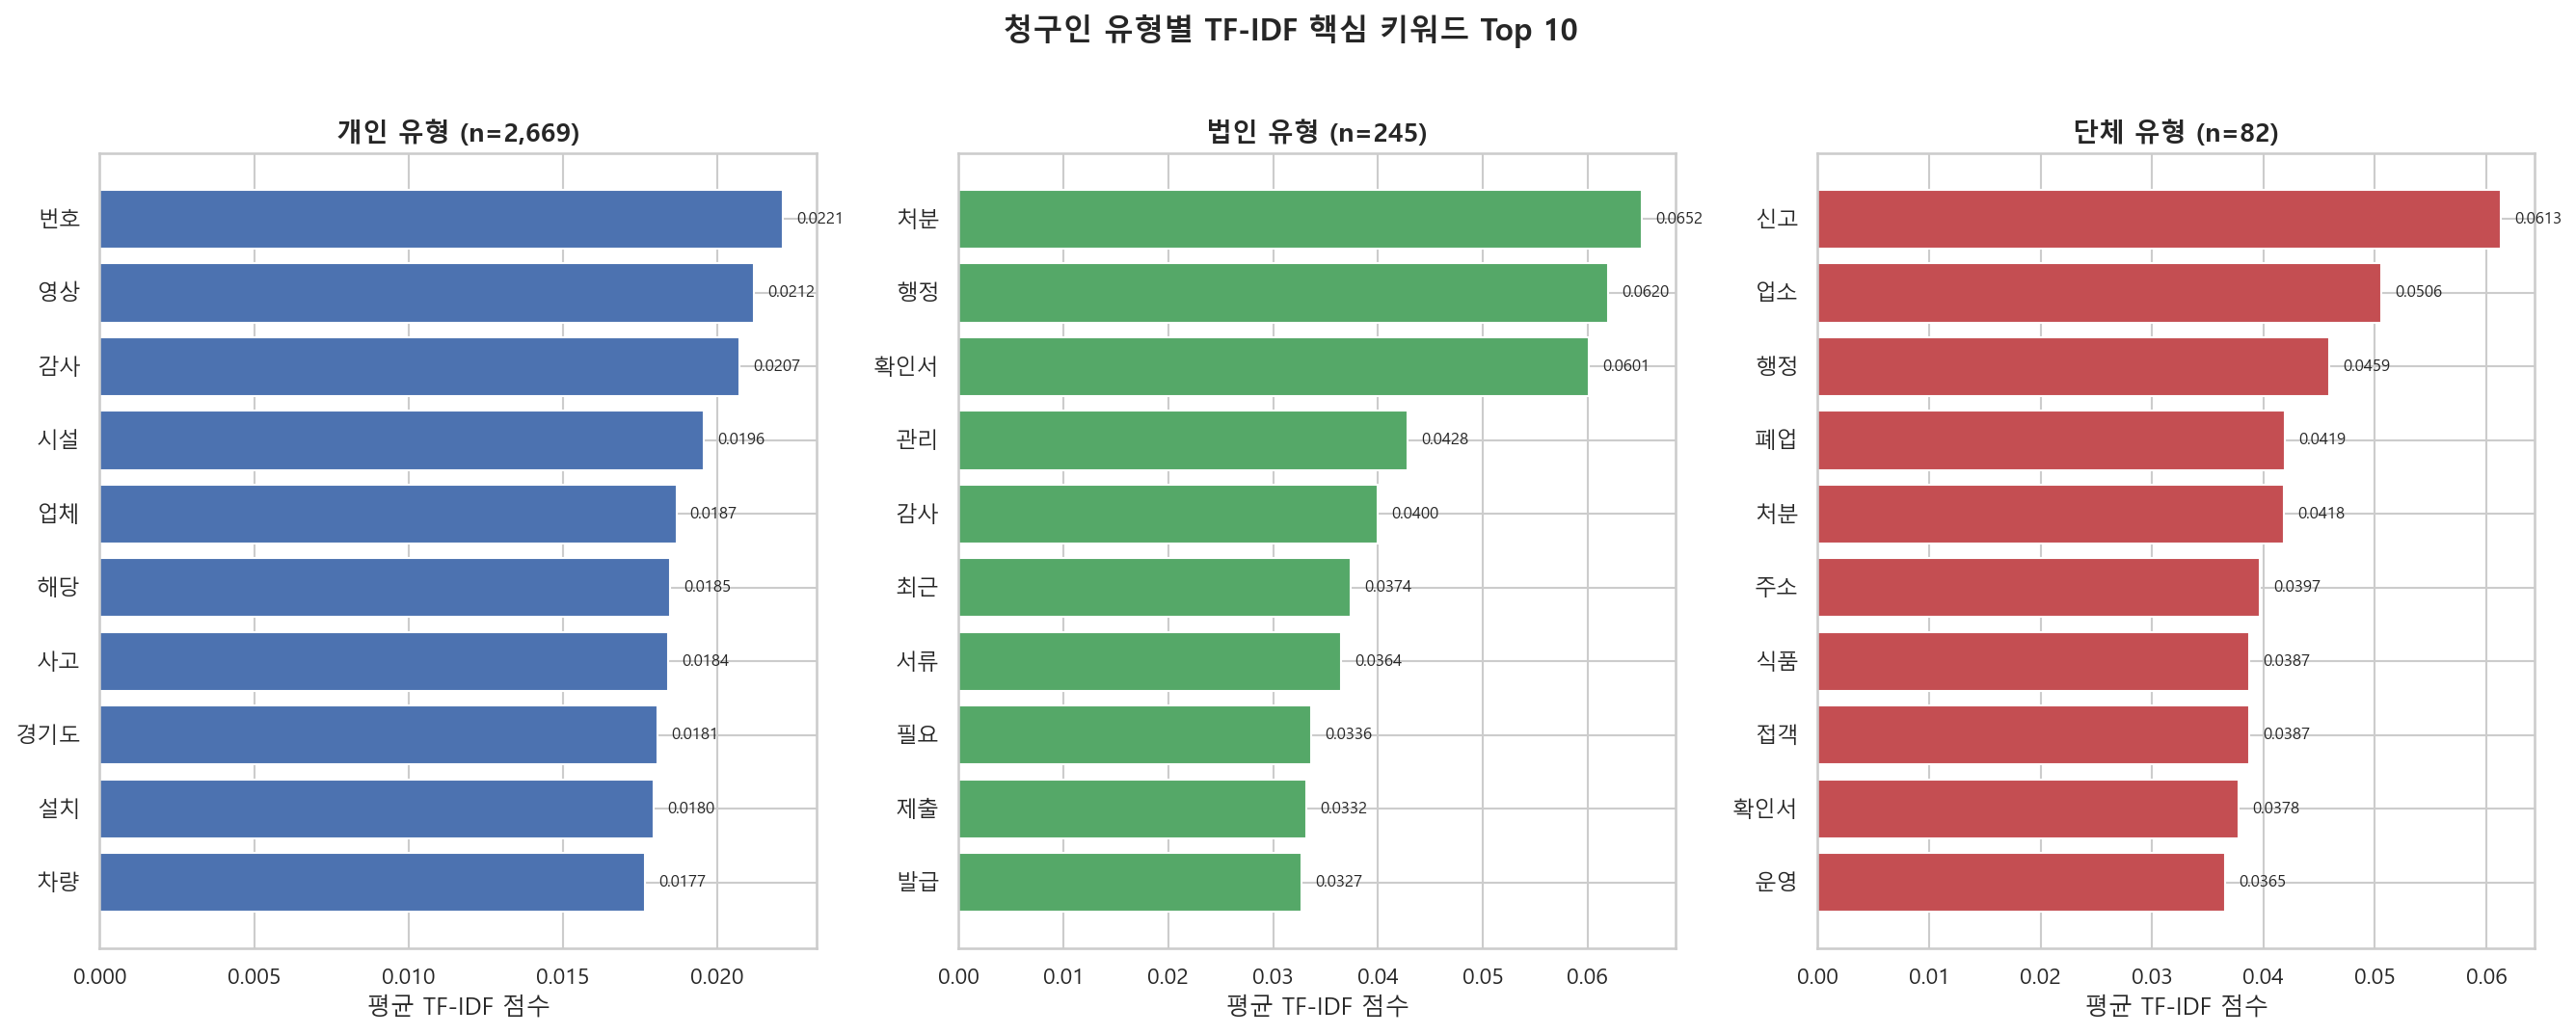

In [ ]:
# ── 시각화 1: 유형별 TF-IDF 키워드 Top 10 막대그래프 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
colors = {'개인': '#4C72B0', '법인': '#55A868', '단체': '#C44E52'}

for ax, utype in zip(axes, ['개인', '법인', '단체']):
    kw = keyword_results[utype]['tfidf'][:10]
    words = [w for w, s in kw][::-1]
    scores = [s for w, s in kw][::-1]
    
    bars = ax.barh(words, scores, color=colors[utype])
    ax.set_title(f'{utype} 유형 (n={keyword_results[utype]["count"]:,})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(LABEL_TASK3_BAR_X)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + max(scores)*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', va='center', fontsize=8)

fig.suptitle(LABEL_TASK3_BAR_TITLE,
             fontsize=15, fontweight='bold', y=1.02)
fix_korean_font(fig)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '태스크3_유형별_키워드_막대그래프.png'),
            dpi=200, bbox_inches='tight')
plt.show()

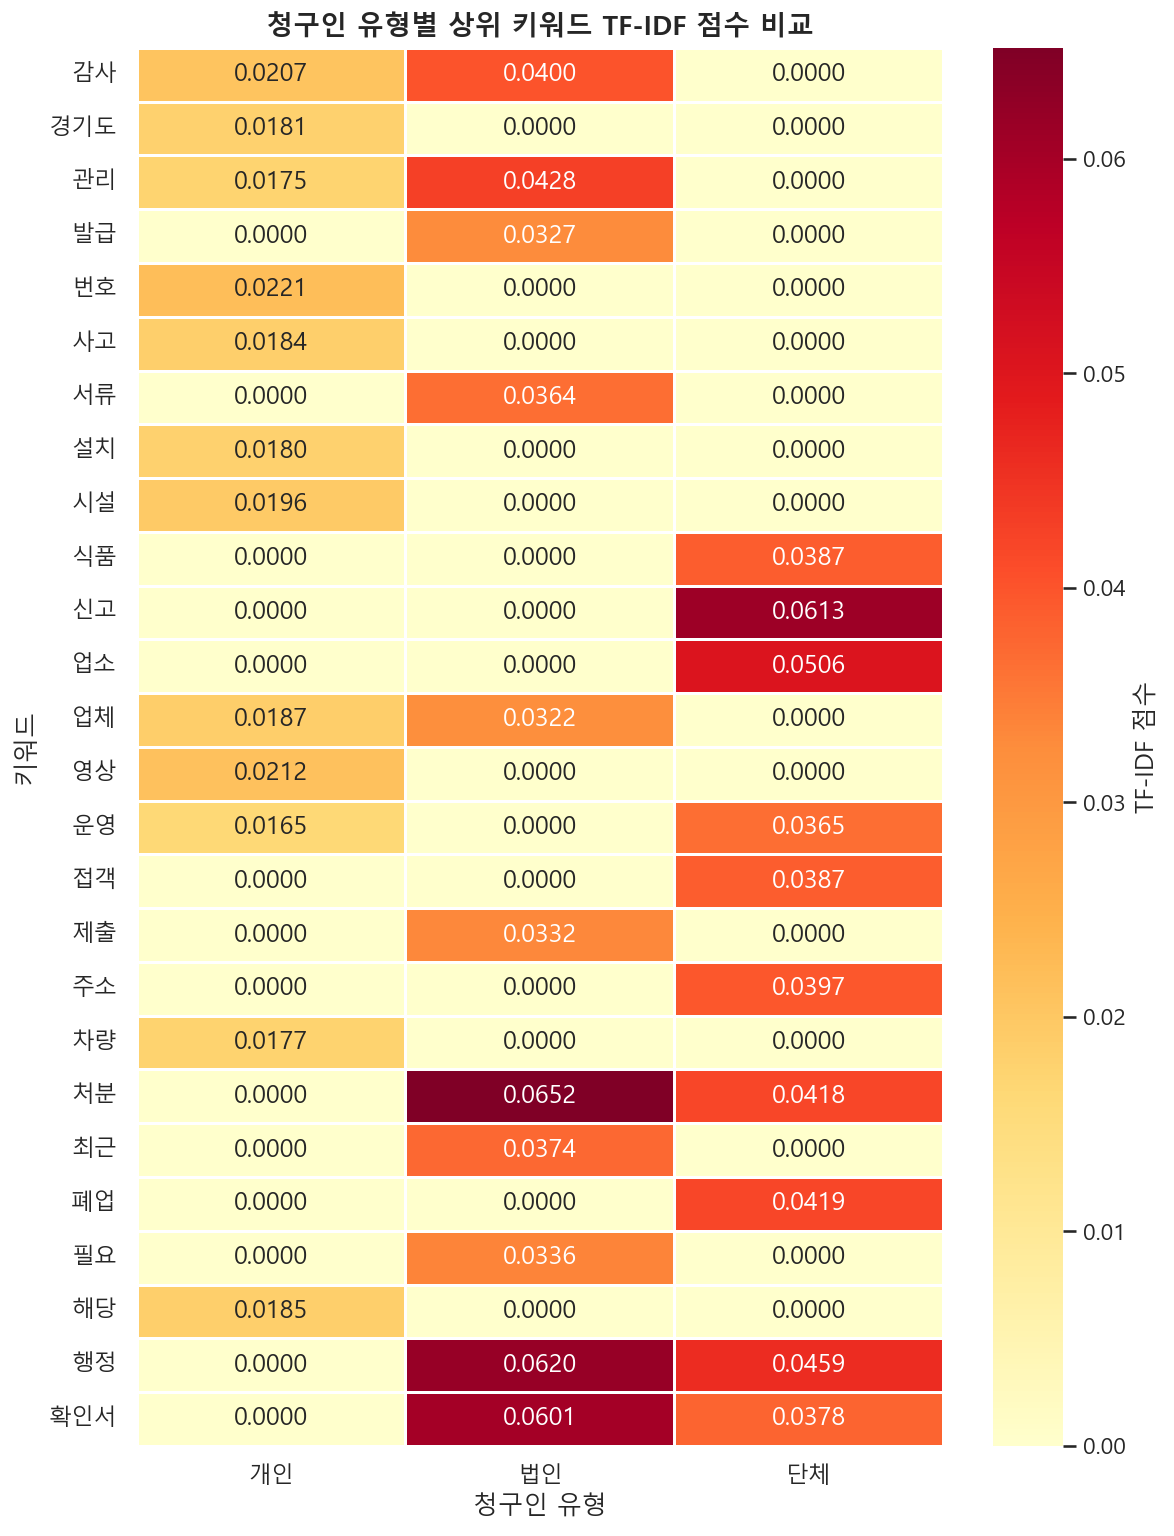

In [ ]:
# ── 시각화 2: 유형별 키워드 TF-IDF 점수 비교 히트맵 ──
all_keywords = set()
for utype in ['개인', '법인', '단체']:
    for word, score in keyword_results[utype]['tfidf'][:10]:
        all_keywords.add(word)

all_keywords = sorted(all_keywords)
heatmap_data = pd.DataFrame(0.0, index=all_keywords, columns=['개인', '법인', '단체'])

for utype in ['개인', '법인', '단체']:
    kw_dict = {w: s for w, s in keyword_results[utype]['tfidf']}
    for word in all_keywords:
        if word in kw_dict:
            heatmap_data.loc[word, utype] = kw_dict[word]

fig, ax = plt.subplots(figsize=(8, max(6, len(all_keywords) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': LABEL_TASK3_BAR_X})
ax.set_title(LABEL_TASK3_HEATMAP_TITLE,
             fontsize=13, fontweight='bold')
ax.set_xlabel(LABEL_TASK3_HEATMAP_X)
ax.set_ylabel(LABEL_TASK3_HEATMAP_Y)
fix_korean_font(fig)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '태스크3_유형별_키워드_히트맵.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [7]:
# ── 표: 유형별 핵심 키워드 정리 ──
rows = []
for utype in ['개인', '법인', '단체']:
    for rank, (word, score) in enumerate(keyword_results[utype]['tfidf'][:TOP_N], 1):
        rows.append({'청구인유형': utype, '순위': rank, '키워드': word,
                     'TF-IDF 점수': round(score, 6), '방법': 'TF-IDF'})
    for rank, (word, count) in enumerate(keyword_results[utype]['freq'][:TOP_N], 1):
        rows.append({'청구인유형': utype, '순위': rank, '키워드': word,
                     '빈도': count, '방법': '빈도'})

keyword_df = pd.DataFrame(rows)

# TF-IDF 상위 10 (피벗 테이블)
print('[ 유형별 TF-IDF 핵심 키워드 Top 10 ]')
tfidf_pivot = keyword_df[keyword_df['방법']=='TF-IDF'][['청구인유형','순위','키워드']].pivot(
    index='순위', columns='청구인유형', values='키워드')[['개인','법인','단체']].head(10)
display(tfidf_pivot)

# 빈도 상위 10 (피벗 테이블)
print('\n[ 유형별 빈출 키워드 Top 10 ]')
freq_pivot = keyword_df[keyword_df['방법']=='빈도'][['청구인유형','순위','키워드']].pivot(
    index='순위', columns='청구인유형', values='키워드')[['개인','법인','단체']].head(10)
display(freq_pivot)

# CSV 저장
keyword_df.to_csv(os.path.join(OUTPUT_DIR, '유형별_핵심키워드.csv'),
                  index=False, encoding='utf-8-sig')
print('\n유형별 키워드 CSV 저장 완료')

[ 유형별 TF-IDF 핵심 키워드 Top 10 ]


청구인유형,개인,법인,단체
순위,,,
1,번호,처분,신고
2,영상,행정,업소
3,감사,확인서,행정
4,시설,관리,폐업
5,업체,감사,처분
6,해당,최근,주소
7,사고,서류,식품
8,경기도,필요,접객
9,설치,제출,확인서



[ 유형별 빈출 키워드 Top 10 ]


청구인유형,개인,법인,단체
순위,,,
1,미군,처분,신고
2,번호,행정,방지
3,시설,관리,위조
4,영상,시설,기술
5,사업,업체,봉투
6,해당,감사,업소
7,차량,확인서,포함
8,관리,사업장,행정
9,사고,오염,주소



유형별 키워드 CSV 저장 완료


---
## 태스크 4: 유사·반복 청구 분석

**TF-IDF + 코사인 유사도**를 활용하여 유사 사례의 유사·반복 청구를 탐지하고,  
핵심 키워드를 추출하여 청구 발생의 원인 및 유형을 분석한다.

### 유사도 방법 선택 근거
| 방법 | 장점 | 단점 | 선택 여부 |
|------|------|------|----------|
| **코사인 유사도** | 문서 길이에 무관, TF-IDF 가중치 활용 | 빈도 차이 무시 | **선택** |
| 유클리드 거리 | 직관적 | 고차원에서 의미 약화 | - |
| 자카드 유사도 | 이진 비교에 강함 | TF-IDF 가중치 활용 불가 | - |

> TF-IDF + 코사인 유사도는 문서 유사도 분석의 사실상 표준으로,  
> 문서 길이 차이가 큰 청구 데이터에서 가장 안정적인 성능을 보인다.

In [13]:
# ── TF-IDF 벡터화 & 코사인 유사도 계산 ──
print('TF-IDF 벡터화 중...')
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'(?u)\b\w+\b',
    min_df=2, max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True, norm='l2'
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_valid['결합문서'])
print(f'TF-IDF 매트릭스: {tfidf_matrix.shape}')

print('코사인 유사도 매트릭스 계산 중...')
sim_matrix = cosine_similarity(tfidf_matrix)
print(f'유사도 매트릭스: {sim_matrix.shape}')

# 상삼각 유사도 추출 (자기자신 제외)
upper_idx = np.triu_indices(sim_matrix.shape[0], k=1)
sim_scores = sim_matrix[upper_idx]

print(f'\n유사도 분포 통계:')
stats = pd.DataFrame({
    '통계': ['평균', '중앙값', '표준편차', '90 퍼센타일', '95 퍼센타일', '99 퍼센타일'],
    '값': [sim_scores.mean(), np.median(sim_scores), sim_scores.std(),
           np.percentile(sim_scores, 90), np.percentile(sim_scores, 95),
           np.percentile(sim_scores, 99)]
})
stats['값'] = stats['값'].round(4)
display(stats.set_index('통계'))

print(f'\n임계값별 {TERM_SIM_REPEAT} 후보 현황:')
threshold_rows = []
for th in [0.65, 0.75, 0.85, 0.95]:
    mask = sim_scores >= th
    pair_count = int(mask.sum())

    if pair_count > 0:
        pair_positions = np.where(mask)[0]
        idx_i = upper_idx[0][pair_positions]
        idx_j = upper_idx[1][pair_positions]
        unique_doc_count = len(set(idx_i.tolist()) | set(idx_j.tolist()))
        mean_sim = float(sim_scores[mask].mean())
    else:
        unique_doc_count = 0
        mean_sim = 0.0

    threshold_rows.append({
        '임계값': th,
        '문서쌍 수': pair_count,
        '고유 문서 수': unique_doc_count,
        '평균 유사도': round(mean_sim, 3)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df['문서쌍 수'] = threshold_df['문서쌍 수'].map(lambda x: f'{x:,}')
threshold_df['고유 문서 수'] = threshold_df['고유 문서 수'].map(lambda x: f'{x:,}')
display(threshold_df)

print('\n해석 가이드:')
print('- 실무 후보 탐색은 0.65~0.85 구간만으로도 경향 파악이 충분함')
print('- 0.95 이상은 거의 문구가 매우 유사한 복붙 수준만 남아 후보 수가 급감할 수 있음')
print('- 보수적 기준 확인용으로는 0.95 한 줄을 보조표로 제시하는 방법이 적절함')

TF-IDF 벡터화 중...
TF-IDF 매트릭스: (2996, 19392)
코사인 유사도 매트릭스 계산 중...
유사도 매트릭스: (2996, 2996)

유사도 분포 통계:


,값
통계,
평균,0.0127
중앙값,0.0000
표준편차,0.0482
90 퍼센타일,0.0254
95 퍼센타일,0.0433
99 퍼센타일,0.2126



임계값별 유사·반복 청구 후보 현황:


,임계값,문서쌍 수,고유 문서 수,평균 유사도
0,0.65,"5,735","1,364",0.869
1,0.75,"4,481","1,205",0.918
2,0.85,"3,269","1,037",0.960
3,0.95,"2,164",793,0.997



해석 가이드:
- 실무 후보 탐색은 0.65~0.85 구간만으로도 경향 파악이 충분함
- 0.95 이상은 거의 문구가 매우 유사한 복붙 수준만 남아 후보 수가 급감할 수 있음
- 보수적 기준 확인용으로는 0.95 한 줄을 보조표로 제시하는 방법이 적절함


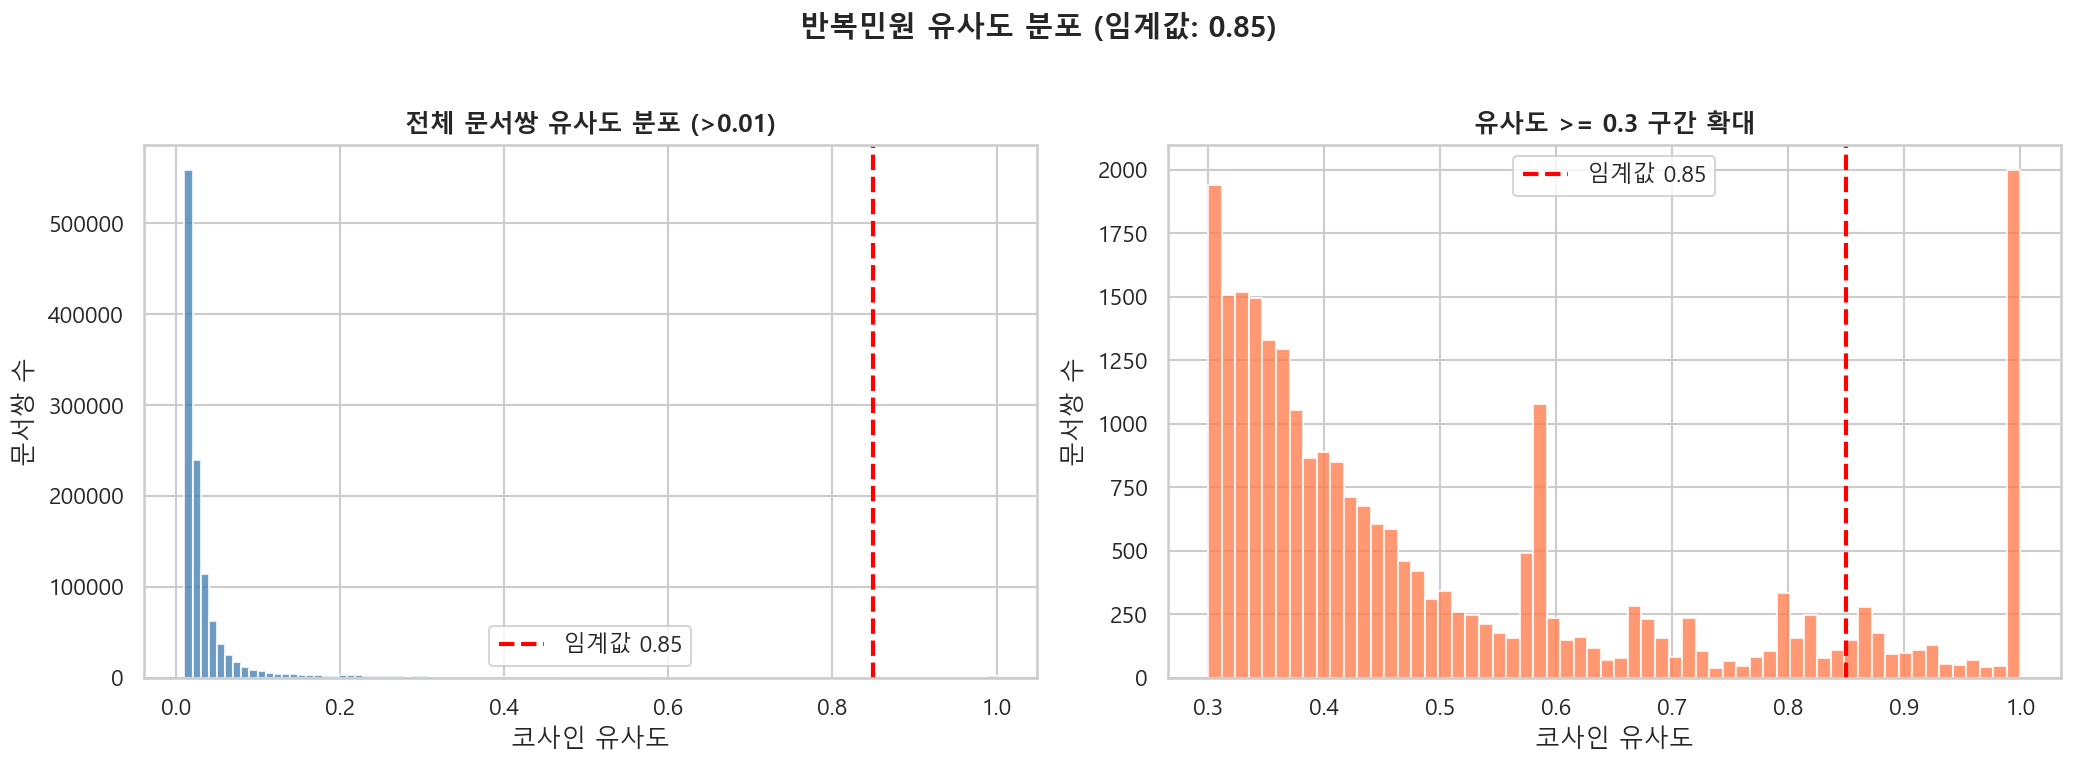

In [ ]:
# ── 시각화 1: 유사도 분포 히스토그램 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 분포
nonzero = sim_scores[sim_scores > 0.01]
axes[0].hist(nonzero, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=SIMILARITY_THRESHOLD, color='red', linestyle='--',
                linewidth=2, label=f'임계값 {SIMILARITY_THRESHOLD}')
axes[0].set_title(LABEL_TASK4_SIM_HIST_SUB_ALL, fontsize=12, fontweight='bold')
axes[0].set_xlabel(LABEL_TASK4_SIM_X)
axes[0].set_ylabel(LABEL_TASK4_SIM_Y)
axes[0].legend()

# 고유사도 구간 확대
high_sim = sim_scores[sim_scores >= 0.3]
axes[1].hist(high_sim, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(x=SIMILARITY_THRESHOLD, color='red', linestyle='--',
                linewidth=2, label=f'임계값 {SIMILARITY_THRESHOLD}')
axes[1].set_title(LABEL_TASK4_SIM_HIST_SUB_HIGH, fontsize=12, fontweight='bold')
axes[1].set_xlabel(LABEL_TASK4_SIM_X)
axes[1].set_ylabel(LABEL_TASK4_SIM_Y)
axes[1].legend()

fig.suptitle(f'{LABEL_TASK4_SIM_HIST_TITLE} (임계값: {SIMILARITY_THRESHOLD})',
             fontsize=14, fontweight='bold', y=1.02)
fix_korean_font(fig)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, FILE_TASK4_SIM_HIST),
            dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# ── 유사·반복 청구 클러스터링 (Union-Find) ──
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return
        if self.rank[ra] < self.rank[rb]: self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]: self.parent[rb] = ra
        else: self.parent[rb] = ra; self.rank[ra] += 1

print(f'임계값 {SIMILARITY_THRESHOLD} 이상 문서쌍 추출 중...')
mask = sim_scores >= SIMILARITY_THRESHOLD
pair_positions = np.where(mask)[0]
idx_i = upper_idx[0][pair_positions]
idx_j = upper_idx[1][pair_positions]

unique_docs = set(idx_i.tolist()) | set(idx_j.tolist())
print(f'유사 문서쌍: {len(pair_positions):,}쌍')
print(f'관련 고유 문서: {len(unique_docs):,}건')

# Union-Find 클러스터링
uf = UnionFind(len(df_valid))
for i, j in zip(idx_i, idx_j):
    uf.union(int(i), int(j))

cluster_map = defaultdict(list)
for idx in unique_docs:
    cluster_map[uf.find(int(idx))].append(int(idx))

clusters = sorted(cluster_map.values(), key=len, reverse=True)
print(f'{TERM_SIM_REPEAT} 클러스터 수: {len(clusters)}')

# 클러스터 상세 정보
cluster_info = []
for cid, members in enumerate(clusters, 1):
    receipts = df_valid.loc[members, '접수번호'].astype(str).tolist()
    title = str(df_valid.loc[members[0], '청구제목_보정'])[:60]
    tokens = [t for idx in members for t in df_valid.loc[idx, '결합토큰']]
    top_kw = [w for w, c in Counter(tokens).most_common(5)]
    utype_dist = df_valid.loc[members, '청구인유형'].value_counts().to_dict()
    
    cluster_info.append({
        'ID': cid, '문서수': len(members),
        '대표제목': title,
        '핵심키워드': ', '.join(top_kw),
        '유형분포': str(utype_dist),
        '접수번호': ' | '.join(receipts[:10]) + ('...' if len(receipts) > 10 else '')
    })

cluster_df = pd.DataFrame(cluster_info)
print(f'\n상위 10개 {TERM_SIM_REPEAT} 클러스터:')
display(cluster_df.head(10)[['ID', '문서수', '대표제목', '핵심키워드']])

임계값 0.85 이상 문서쌍 추출 중...
유사 문서쌍: 3,269쌍
관련 고유 문서: 1,037건
유사·반복 청구 클러스터 수: 335

상위 10개 유사·반복 청구 클러스터:


,ID,문서수,대표제목,핵심키워드
0,1,49,주한미군 김상진 미군 육군 소령,"미군, 군사법원, 김상진, 육군, 소령"
1,2,40,행정처분 내역 확인서 요청(의왕시 자원관리과),"행정, 처분, 확인서, 발급, 자원"
2,3,37,미군 주한미군 김상진 소령,"미군, 육군, 김상진, 소령, 군사법원"
3,4,18,주한미군 김상진 미군 육군 소령,"년대, 조현아, 부회장, 미군, 가치"
4,5,14,미군 주한미군 김상진 소령 입니다,"미군, 김상진, 소령, 외교부, 육군"
5,6,13,기업은행 사거리 교차로 CCTV,"관계, 영상, 인물, 번호, 장소"
6,7,13,11월 제약회사별 약품 사용 통계 신청,"제약, 회사, 약품, 사용, 통계"
7,8,12,12월 관 내 일반 음식점 중 신규 허가 업소와 지위 승계업소 현황,"업소, 연락처, 변경, 신규, 지위"
8,9,11,토양오염 관련 행정처분 사업장 현황 정보공개 요청건,"오염, 종결, 토양, 행정, 처분"
9,10,11,미군 주한미군 김상진 소령 입니다,"미군, 김상진, 소령, 외교부, 육군"


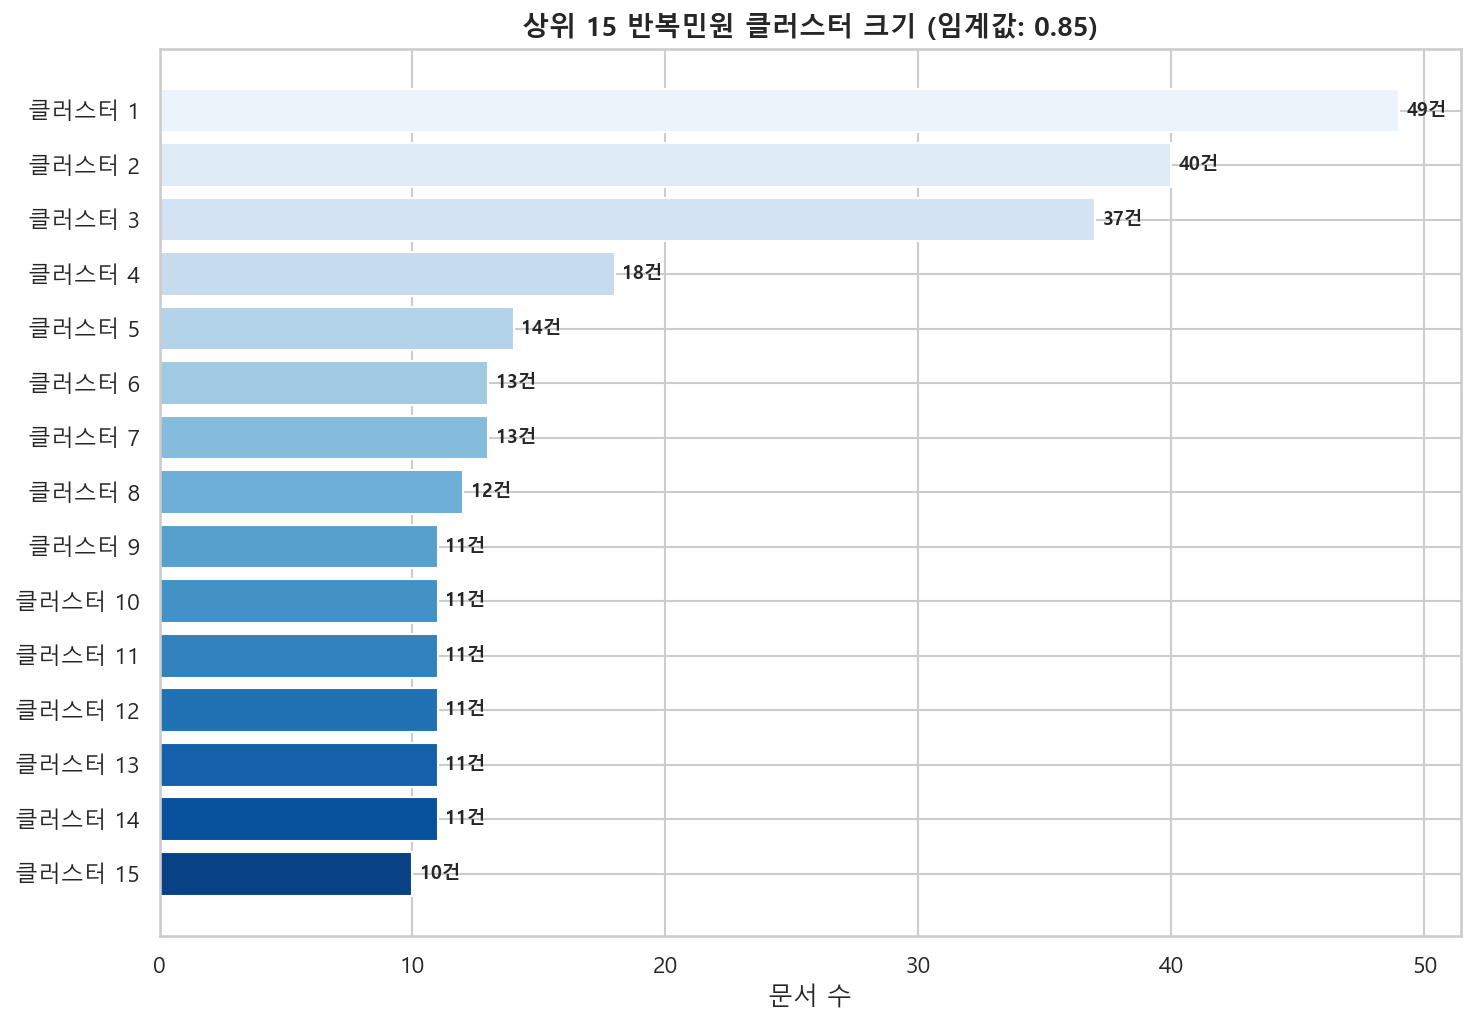

In [ ]:
# ── 시각화 2: 상위 유사·반복 청구 클러스터 크기 막대그래프 ──
top_clusters = cluster_df.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
labels = [f'클러스터 {r.ID}' for _, r in top_clusters.iterrows()][::-1]
values = top_clusters['문서수'].values[::-1]

bars = ax.barh(labels, values,
               color=sns.color_palette('Blues_r', len(top_clusters)))

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val}{COUNT_UNIT}', va='center', fontsize=9, fontweight='bold')

ax.set_title(f'{LABEL_TASK4_CLUSTER_BAR_TITLE} (임계값: {SIMILARITY_THRESHOLD})',
             fontsize=13, fontweight='bold')
ax.set_xlabel(LABEL_TASK4_CLUSTER_BAR_X)
fix_korean_font(fig)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, FILE_TASK4_CLUSTER_BAR),
            dpi=200, bbox_inches='tight')
plt.show()

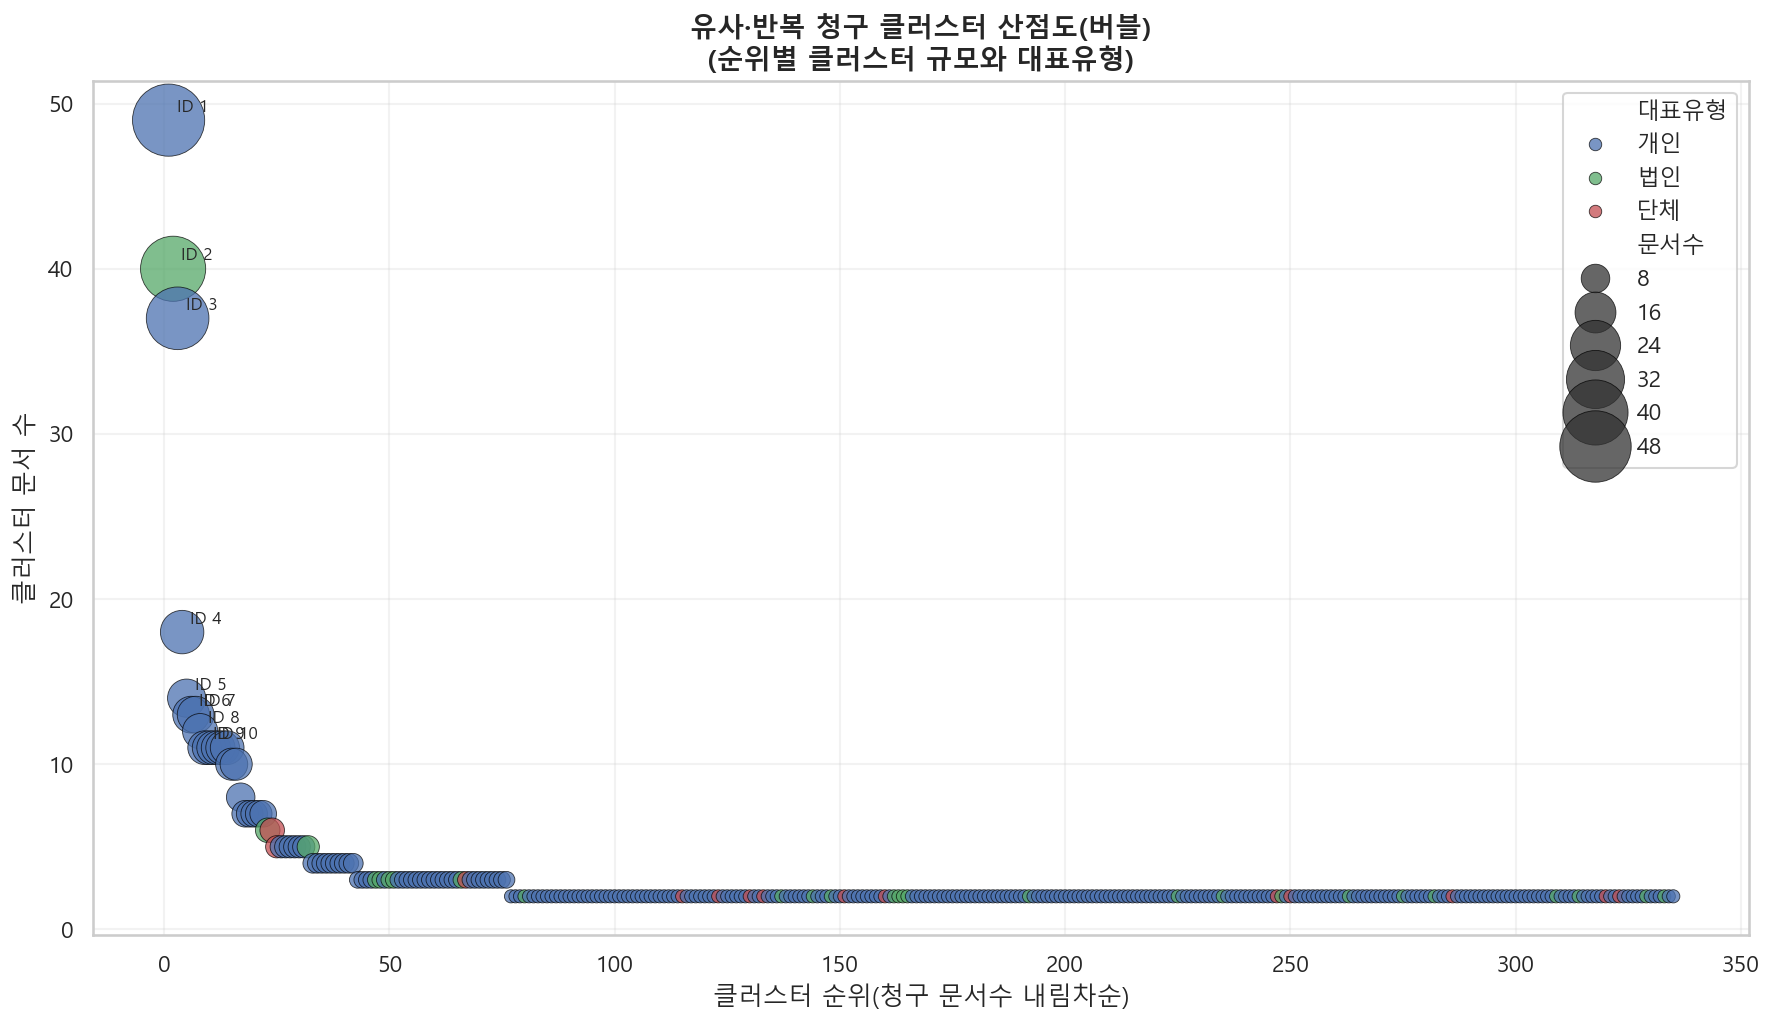

총 클러스터: 335개
저장 완료: 태스크4_유사_반복_청구_클러스터_산점도.png, 유사_반복_청구_클러스터_전체목록.csv, 유사_반복_청구_클러스터_전체목록.txt


,순위,ID,문서수,대표유형,대표제목,핵심키워드,유형분포,접수번호
0,1,1,49,개인,주한미군 김상진 미군 육군 소령,"미군, 군사법원, 김상진, 육군, 소령",{'개인': 49},14887903 | 14861326 | 14824344 | 14800056 | 14...
1,2,2,40,법인,행정처분 내역 확인서 요청(의왕시 자원관리과),"행정, 처분, 확인서, 발급, 자원","{'법인': 34, '단체': 6}",15795918 | 15617664 | 15592682 | 15566444 | 15...
2,3,3,37,개인,미군 주한미군 김상진 소령,"미군, 육군, 김상진, 소령, 군사법원",{'개인': 37},15525005 | 15515848 | 15509459 | 15507771 | 15...
3,4,4,18,개인,주한미군 김상진 미군 육군 소령,"년대, 조현아, 부회장, 미군, 가치",{'개인': 18},15085527 | 15080403 | 14906716 | 14902199 | 14...
4,5,5,14,개인,미군 주한미군 김상진 소령 입니다,"미군, 김상진, 소령, 외교부, 육군",{'개인': 14},15811677 | 15794256 | 15782155 | 15780607 | 15...
5,6,6,13,개인,기업은행 사거리 교차로 CCTV,"관계, 영상, 인물, 번호, 장소",{'개인': 13},15642219 | 15509923 | 15305099 | 15158046 | 14...
6,7,7,13,개인,11월 제약회사별 약품 사용 통계 신청,"제약, 회사, 약품, 사용, 통계",{'개인': 13},15608725 | 15374348 | 15198107 | 15171402 | 14...
7,8,8,12,개인,12월 관 내 일반 음식점 중 신규 허가 업소와 지위 승계업소 현황,"업소, 연락처, 변경, 신규, 지위",{'개인': 12},15746857 | 15506456 | 15296314 | 15063498 | 14...
8,9,9,11,개인,토양오염 관련 행정처분 사업장 현황 정보공개 요청건,"오염, 종결, 토양, 행정, 처분",{'개인': 11},15747310 | 15507158 | 15344634 | 15100051 | 14...
9,10,10,11,개인,미군 주한미군 김상진 소령 입니다,"미군, 김상진, 소령, 외교부, 육군",{'개인': 11},15650991 | 15636055 | 15632755 | 15628450 | 15...


In [15]:
# ── 시각화 3: 유사·반복 청구 클러스터 산점도(버블) + 전체 목록 저장 ──
import ast

# cluster_df는 앞 셀(클러스터링 셀)에서 생성됨
if 'cluster_df' not in globals() or cluster_df.empty:
    raise ValueError('cluster_df가 없습니다. 먼저 클러스터링 셀을 실행해 주세요.')

plot_df = cluster_df.copy().sort_values(['문서수', 'ID'], ascending=[False, True]).reset_index(drop=True)
plot_df['순위'] = np.arange(1, len(plot_df) + 1)

# 유형분포에서 대표 유형 추출

def get_main_type(dist_text):
    try:
        dist = ast.literal_eval(dist_text)
        if isinstance(dist, dict) and len(dist) > 0:
            return sorted(dist.items(), key=lambda x: x[1], reverse=True)[0][0]
    except:
        pass
    return '기타'

plot_df['대표유형'] = plot_df['유형분포'].apply(get_main_type)

# 버블 산점도 (x: 클러스터 순위, y: 문서수, size: 문서수, color: 대표유형)
fig, ax = plt.subplots(figsize=(12, 7))
palette = {'개인': '#4C72B0', '법인': '#55A868', '단체': '#C44E52', '기타': '#8172B2'}

sns.scatterplot(
    data=plot_df,
    x='순위', y='문서수',
    size='문서수', sizes=(40, 1200),
    hue='대표유형', palette=palette,
    alpha=0.75, edgecolor='black', linewidth=0.4,
    ax=ax
)

# 상위 10개 클러스터 라벨 표시
for _, row in plot_df.head(10).iterrows():
    ax.annotate(
        f"ID {int(row['ID'])}",
        (row['순위'], row['문서수']),
        xytext=(4, 4), textcoords='offset points',
        fontsize=8
    )

ax.set_title(LABEL_TASK4_CLUSTER_BUBBLE_TITLE, fontsize=13, fontweight='bold')
ax.set_xlabel(LABEL_TASK4_CLUSTER_BUBBLE_X)
ax.set_ylabel(LABEL_TASK4_CLUSTER_BUBBLE_Y)
ax.grid(alpha=0.25)

fix_korean_font(fig)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, FILE_TASK4_CLUSTER_BUBBLE), dpi=200, bbox_inches='tight')
plt.show()

# 전체 클러스터 목록 저장
cluster_list_df = plot_df[['순위', 'ID', '문서수', '대표유형', '대표제목', '핵심키워드', '유형분포', '접수번호']].copy()
cluster_list_df.to_csv(
    os.path.join(OUTPUT_DIR, FILE_SIM_REPEAT_CLUSTER_LIST_CSV),
    index=False, encoding='utf-8-sig'
)

# 텍스트 목록도 함께 저장(요약형)
with open(os.path.join(OUTPUT_DIR, FILE_SIM_REPEAT_CLUSTER_LIST_TXT), 'w', encoding='utf-8') as f:
    f.write(f'# {TERM_SIM_REPEAT} 클러스터 전체 목록 (문서수 내림차순)\n')
    f.write(f'# 총 클러스터: {len(cluster_list_df):,}\n\n')
    for _, r in cluster_list_df.iterrows():
        f.write(f"[{int(r['순위'])}] ID {int(r['ID'])} | 문서수 {int(r['문서수'])} | 대표유형 {r['대표유형']}\n")
        f.write(f"  대표제목: {r['대표제목']}\n")
        f.write(f"  핵심키워드: {r['핵심키워드']}\n")
        f.write(f"  접수번호: {r['접수번호']}\n\n")

print(f'총 클러스터: {len(cluster_list_df):,}개')
print(f'저장 완료: {FILE_TASK4_CLUSTER_BUBBLE}, {FILE_SIM_REPEAT_CLUSTER_LIST_CSV}, {FILE_SIM_REPEAT_CLUSTER_LIST_TXT}')
display(cluster_list_df.head(20))

In [18]:
# ── 표: 유사·반복 청구 핵심 키워드 추출 ──
repeated_indices = list(unique_docs)
repeated_df = df_valid.loc[repeated_indices]

# 빈도 기반 키워드
all_tokens = [t for tokens in repeated_df['결합토큰'] for t in tokens]
freq_keywords = Counter(all_tokens).most_common(TOP_N)

# TF-IDF 기반 키워드
repeated_docs = repeated_df['결합문서'].tolist()
vec = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', min_df=2, max_df=0.85, sublinear_tf=True)
mat = vec.fit_transform(repeated_docs)
names = np.array(vec.get_feature_names_out())
scores_arr = np.asarray(mat.mean(axis=0)).ravel()
top_tfidf_idx = np.argsort(scores_arr)[::-1][:TOP_N]
tfidf_keywords = [(names[i], scores_arr[i]) for i in top_tfidf_idx if scores_arr[i] > 0]

# 빈도 키워드 표
print(f'[ {TERM_SIM_REPEAT} 핵심 키워드 - 빈도 기반 ]')
freq_kw_df = pd.DataFrame(freq_keywords, columns=['키워드', '빈도'])
freq_kw_df.index = range(1, len(freq_kw_df) + 1)
freq_kw_df.index.name = '순위'
display(freq_kw_df)

# TF-IDF 키워드 표
print(f'\n[ {TERM_SIM_REPEAT} 핵심 키워드 - TF-IDF 기반 ]')
tfidf_kw_df = pd.DataFrame(tfidf_keywords, columns=['키워드', 'TF-IDF 점수'])
tfidf_kw_df['TF-IDF 점수'] = tfidf_kw_df['TF-IDF 점수'].round(6)
tfidf_kw_df.index = range(1, len(tfidf_kw_df) + 1)
tfidf_kw_df.index.name = '순위'
display(tfidf_kw_df)

# 클러스터 요약 상위 10
print(f'\n[ {TERM_SIM_REPEAT} 클러스터 요약 상위 10 ]')
display(cluster_df.head(10)[['ID', '문서수', '대표제목', '핵심키워드', '유형분포']])

[ 유사·반복 청구 핵심 키워드 - 빈도 기반 ]


,키워드,빈도
순위,,
1,미군,1191
2,김상진,713
3,소령,706
4,육군,634
5,영상,399
6,번호,388
7,업체,377
8,관리,357
9,차량,357



[ 유사·반복 청구 핵심 키워드 - TF-IDF 기반 ]


,키워드,TF-IDF 점수
순위,,
1,미군,0.039112
2,김상진,0.030202
3,소령,0.029443
4,육군,0.027313
5,오염,0.026462
6,토양,0.026012
7,감사,0.025924
8,처분,0.023823
9,영상,0.023478



[ 유사·반복 청구 클러스터 요약 상위 10 ]


,ID,문서수,대표제목,핵심키워드,유형분포
0,1,49,주한미군 김상진 미군 육군 소령,"미군, 군사법원, 김상진, 육군, 소령",{'개인': 49}
1,2,40,행정처분 내역 확인서 요청(의왕시 자원관리과),"행정, 처분, 확인서, 발급, 자원","{'법인': 34, '단체': 6}"
2,3,37,미군 주한미군 김상진 소령,"미군, 육군, 김상진, 소령, 군사법원",{'개인': 37}
3,4,18,주한미군 김상진 미군 육군 소령,"년대, 조현아, 부회장, 미군, 가치",{'개인': 18}
4,5,14,미군 주한미군 김상진 소령 입니다,"미군, 김상진, 소령, 외교부, 육군",{'개인': 14}
5,6,13,기업은행 사거리 교차로 CCTV,"관계, 영상, 인물, 번호, 장소",{'개인': 13}
6,7,13,11월 제약회사별 약품 사용 통계 신청,"제약, 회사, 약품, 사용, 통계",{'개인': 13}
7,8,12,12월 관 내 일반 음식점 중 신규 허가 업소와 지위 승계업소 현황,"업소, 연락처, 변경, 신규, 지위",{'개인': 12}
8,9,11,토양오염 관련 행정처분 사업장 현황 정보공개 요청건,"오염, 종결, 토양, 행정, 처분",{'개인': 11}
9,10,11,미군 주한미군 김상진 소령 입니다,"미군, 김상진, 소령, 외교부, 육군",{'개인': 11}


In [21]:
# ── 결과 파일 저장 ──
# 1. 유사·반복 청구 핵심 키워드 CSV
kw_rows = []
for rank, (w, c) in enumerate(freq_keywords, 1):
    kw_rows.append({'방법': '빈도', '순위': rank, '키워드': w, '값': c})
for rank, (w, s) in enumerate(tfidf_keywords, 1):
    kw_rows.append({'방법': 'TF-IDF', '순위': rank, '키워드': w, '값': round(s, 6)})
pd.DataFrame(kw_rows).to_csv(
    os.path.join(OUTPUT_DIR, FILE_SIM_REPEAT_KEYWORD),
    index=False, encoding='utf-8-sig')

# 2. 클러스터 요약 CSV
cluster_df.to_csv(
    os.path.join(OUTPUT_DIR, FILE_SIM_REPEAT_CLUSTER_SUM),
    index=False, encoding='utf-8-sig')

# 3. 접수번호 라벨링 파일
with open(os.path.join(OUTPUT_DIR, FILE_SIM_REPEAT_RECEIPT), 'w', encoding='utf-8') as f:
    f.write(f'# {TERM_SIM_REPEAT} 접수번호 목록\n')
    f.write(f'# 유사도 방법: TF-IDF + 코사인 유사도\n')
    f.write(f'# 임계값: {SIMILARITY_THRESHOLD}\n')
    f.write(f'# 총 클러스터: {len(clusters)}, 총 문서: {len(unique_docs)}\n\n')
    for cid, members in enumerate(clusters, 1):
        receipts = df_valid.loc[members, '접수번호'].astype(str).tolist()
        info = cluster_info[cid - 1]
        f.write(f'## 클러스터 {cid} ({len(members)}건): {info["대표제목"]}\n')
        f.write(f'# 키워드: {info["핵심키워드"]}\n')
        for r in receipts:
            f.write(f'{r}\n')
        f.write('\n')

# 4. 유형별 키워드 CSV (이미 저장됨)
print('저장된 파일 목록:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(('.csv', '.txt', '.png')):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
        print(f'  {f} ({size:,} bytes)')

print('\n모든 결과 저장 완료')

저장된 파일 목록:
  보고서_완성본.txt (13,509 bytes)
  유사_반복_청구_접수번호.txt (64,491 bytes)
  유사_반복_청구_클러스터_전체목록.csv (59,866 bytes)
  유사_반복_청구_클러스터_전체목록.txt (83,830 bytes)
  유사_반복_청구_클러스터요약.csv (56,269 bytes)
  유사_반복_청구_핵심키워드.csv (792 bytes)
  유형별_핵심키워드.csv (3,019 bytes)
  처리상태_유사_반복_청구_후보현황.csv (172 bytes)
  처리상태_전체현황.csv (360 bytes)
  태스크1_처리상태_현황분석.png (145,083 bytes)
  태스크3_유형별_키워드_막대그래프.png (154,661 bytes)
  태스크3_유형별_키워드_히트맵.png (288,198 bytes)
  태스크4_유사_반복_청구_클러스터_산점도.png (198,882 bytes)
  태스크4_유사도분포_히스토그램.png (110,567 bytes)
  태스크4_클러스터_산점도.png (195,827 bytes)
  태스크4_클러스터크기_막대그래프.png (89,715 bytes)

모든 결과 저장 완료


[전체 문서 처리상태 분포]


,처리상태,건수,비율(%)
0,공개완료,2018,67.1
1,정보부존재통지완료,504,16.8
2,청구취하,206,6.9
3,종결처리통지완료,176,5.9
4,이송완료,70,2.3
5,통지완료,14,0.5
6,문서이송(오프라인),7,0.2
7,수수료10일초과예정,5,0.2
8,진정질의통지완료,5,0.2
9,수수료10일초과종결,1,0.0



[second-result 연계] 유사_반복_청구_접수번호.txt 추출 행수: 1,037행
[second-result 연계] 고유 접수번호 수: 1,036건
[second-result 연계] 원본 데이터 매핑 건수: 1,037건
  ※ 접수번호 중복 1건 포함

[유사·반복 청구 후보(접수번호 목록) 처리상태 분포]


,처리상태,건수,비율(%)
0,공개완료,710,68.5
1,종결처리통지완료,122,11.8
2,정보부존재통지완료,110,10.6
3,청구취하,81,7.8
4,이송완료,14,1.4


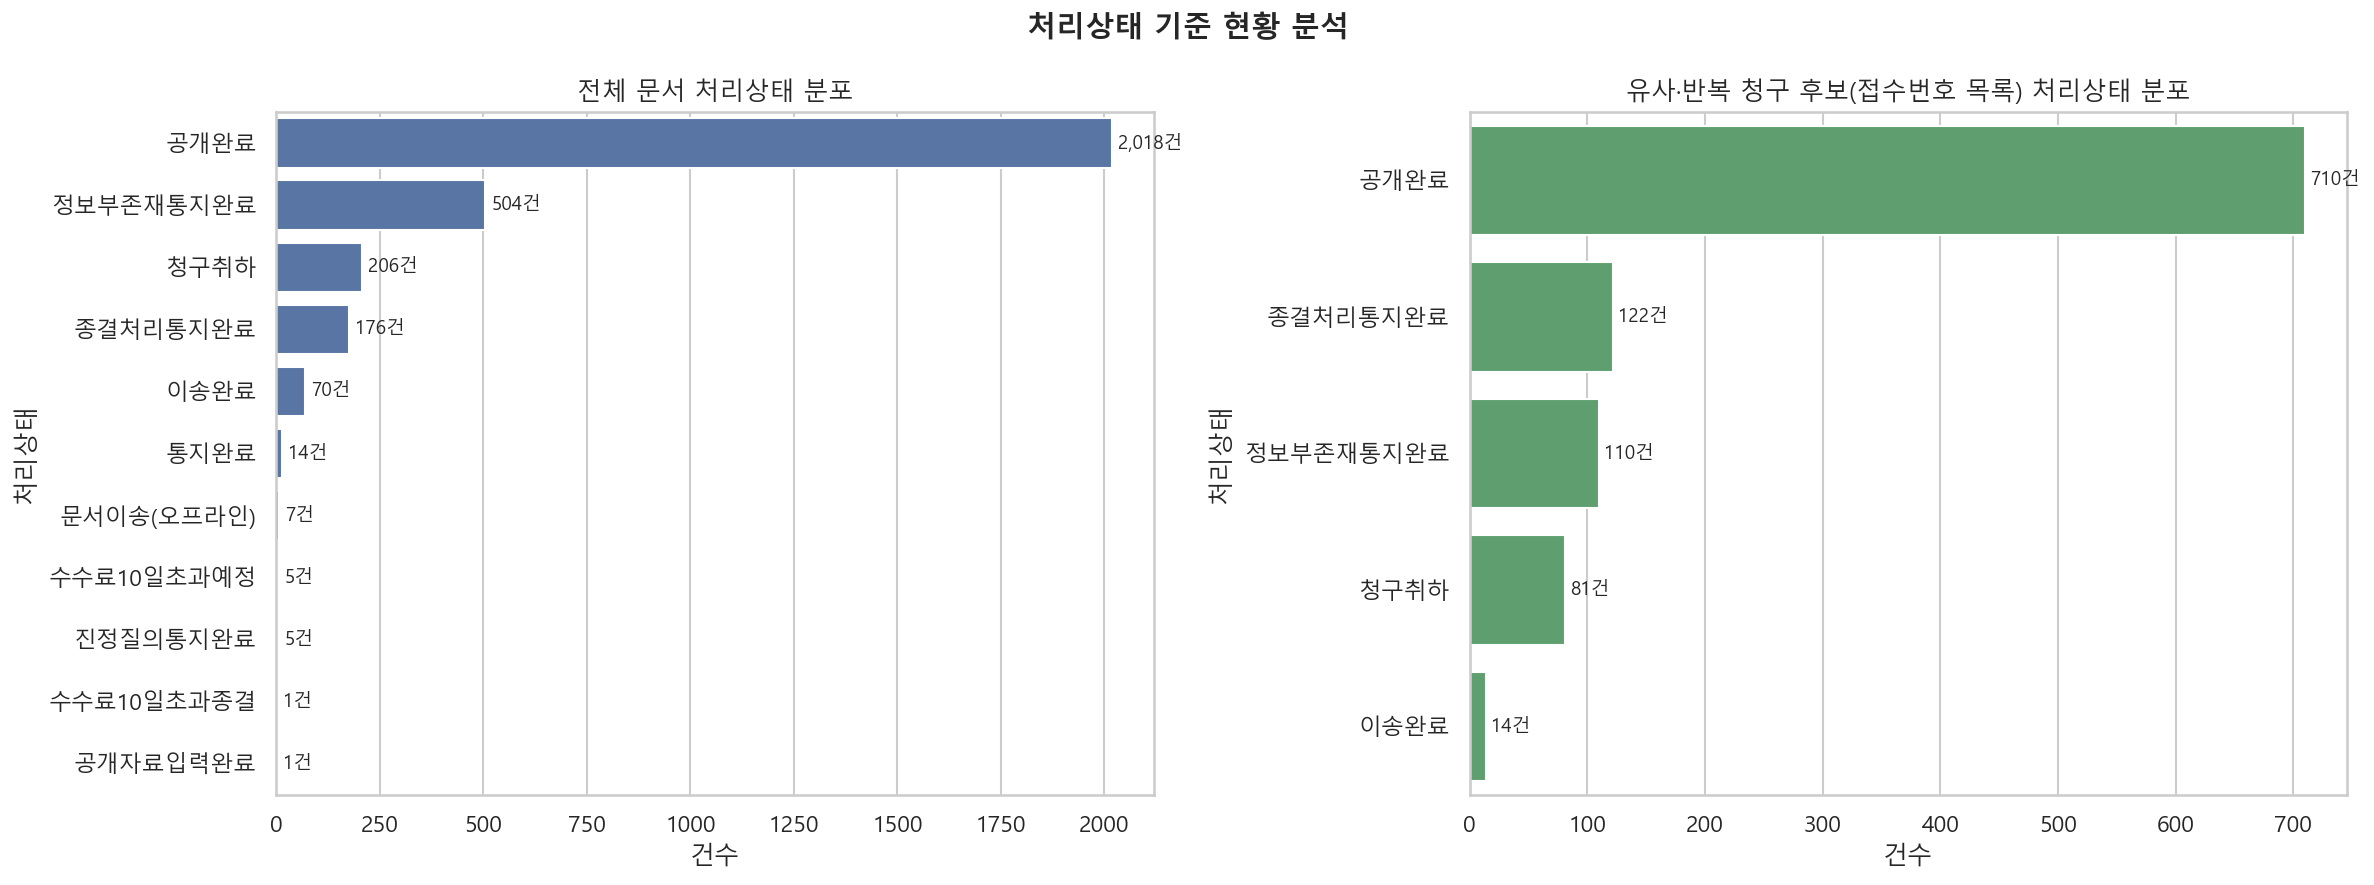


저장 완료: 처리상태_전체현황.csv, 처리상태_유사_반복_청구_후보현황.csv, 태스크1_처리상태_현황분석.png


In [20]:
# ── 태스크 1 보강: 처리상태 기준 현황 분석 (second-result 연계, 단일 셀) ──
from pathlib import Path

# 1) 원본 전체 문서 처리상태 분포
status_series = df['처리상태'].fillna('').astype(str).str.strip()
status_series = status_series.replace('', '공백(미기재)')
status_counts = status_series.value_counts()
status_df = pd.DataFrame({'처리상태': status_counts.index, '건수': status_counts.values})
status_df['비율(%)'] = (status_df['건수'] / len(df) * 100).round(1)

print('[전체 문서 처리상태 분포]')
display(status_df)

# 2) second-result 산출물(유사·반복 청구 접수번호 파일) 기반 처리상태 분포
base = Path(OUTPUT_DIR)
receipt_txt = base / FILE_SIM_REPEAT_RECEIPT

receipt_numbers = []
with open(receipt_txt, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line and line.isdigit():
            receipt_numbers.append(line)

receipt_set = set(receipt_numbers)
repeated_by_txt = df[df['접수번호'].astype(str).isin(receipt_set)].copy()
rep_status = repeated_by_txt['처리상태'].fillna('').astype(str).str.strip().replace('', '공백(미기재)').value_counts()
rep_status_df = pd.DataFrame({'처리상태': rep_status.index, '건수': rep_status.values})
rep_status_df['비율(%)'] = (rep_status_df['건수'] / len(repeated_by_txt) * 100).round(1)

print(f'\n[second-result 연계] {FILE_SIM_REPEAT_RECEIPT} 추출 행수: {len(receipt_numbers):,}행')
print(f'[second-result 연계] 고유 접수번호 수: {len(receipt_set):,}건')
print(f'[second-result 연계] 원본 데이터 매핑 건수: {len(repeated_by_txt):,}건')
if len(receipt_numbers) != len(receipt_set):
    print(f'  ※ 접수번호 중복 {len(receipt_numbers) - len(receipt_set)}건 포함')

print(f'\n[{TERM_SIM_REPEAT} 후보(접수번호 목록) 처리상태 분포]')
display(rep_status_df)

# 3) 결과 저장 (보고서/후속 그래프 작업용)
status_df.to_csv(os.path.join(OUTPUT_DIR, '처리상태_전체현황.csv'), index=False, encoding='utf-8-sig')
rep_status_df.to_csv(os.path.join(OUTPUT_DIR, '처리상태_유사_반복_청구_후보현황.csv'), index=False, encoding='utf-8-sig')

# 4) 시각화 (한 셀에서 동시 수행)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=status_df, x='건수', y='처리상태', ax=axes[0], color='#4C72B0')
axes[0].set_title('전체 문서 처리상태 분포')
axes[0].set_xlabel('건수')
axes[0].set_ylabel('처리상태')
for p in axes[0].patches:
    v = int(p.get_width())
    axes[0].text(p.get_width() + 15, p.get_y() + p.get_height()/2, f'{v:,}{COUNT_UNIT}', va='center', fontsize=9)

sns.barplot(data=rep_status_df, x='건수', y='처리상태', ax=axes[1], color='#55A868')
axes[1].set_title(f'{TERM_SIM_REPEAT} 후보(접수번호 목록) 처리상태 분포')
axes[1].set_xlabel('건수')
axes[1].set_ylabel('처리상태')
for p in axes[1].patches:
    v = int(p.get_width())
    axes[1].text(p.get_width() + 4, p.get_y() + p.get_height()/2, f'{v:,}{COUNT_UNIT}', va='center', fontsize=9)

fig.suptitle('처리상태 기준 현황 분석', fontsize=14, fontweight='bold')
fix_korean_font(fig)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '태스크1_처리상태_현황분석.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f'\n저장 완료: 처리상태_전체현황.csv, 처리상태_유사_반복_청구_후보현황.csv, 태스크1_처리상태_현황분석.png')